In [3]:
from pathlib import Path
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Find the project root before importing from src.
cwd = Path.cwd()
if (cwd / "src" / "load_data.py").exists():
    project_dir = cwd
elif (cwd.parent / "src" / "load_data.py").exists():
    project_dir = cwd.parent
else:
    raise FileNotFoundError(f"Cannot find src/load_data.py in {cwd} or {cwd.parent}")

sys.path.insert(0, str(project_dir))
from src.load_data import load


In [4]:

print("Working directory:", cwd)
print("Using project folder:", project_dir)
df = load()
display(df.head())



Working directory: c:\Users\Administrator\Desktop\ironhack\Mini_Project\Group4-Project\notebooks
Using project folder: c:\Users\Administrator\Desktop\ironhack\Mini_Project\Group4-Project


,Unnamed: 0,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,425390,366,4,2013-04-18,517,1,0,0,0,4422
1,291687,394,6,2015-04-11,694,1,0,0,0,8297
2,411278,807,4,2013-08-29,970,1,1,0,0,9729
3,664714,802,2,2013-05-28,473,1,1,0,0,6513
4,540835,726,4,2013-10-10,1068,1,1,0,0,10882


In [5]:
#Exploratory Data Analysis (EDA)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   Unnamed: 0           640840 non-null  int64
 1   store_ID             640840 non-null  int64
 2   day_of_week          640840 non-null  int64
 3   date                 640840 non-null  str  
 4   nb_customers_on_day  640840 non-null  int64
 5   open                 640840 non-null  int64
 6   promotion            640840 non-null  int64
 7   state_holiday        640840 non-null  str  
 8   school_holiday       640840 non-null  int64
 9   sales                640840 non-null  int64
dtypes: int64(8), str(2)
memory usage: 55.6 MB


In [6]:
#Display the rows and columns of the data frame
df.shape


(640840, 10)

In [7]:
#display the column names of the data frame
df.columns

Index(['Unnamed: 0', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday', 'sales'],
      dtype='str')

In [8]:
#check for missing values in the data frame
df.isnull().sum()

Unnamed: 0             0
store_ID               0
day_of_week            0
date                   0
nb_customers_on_day    0
open                   0
promotion              0
state_holiday          0
school_holiday         0
sales                  0
dtype: int64

In [9]:
#describe the data frame
df.describe()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales
count,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000,640840.000000
mean,355990.675084,558.211348,4.000189,633.398577,0.830185,0.381718,0.178472,5777.469011
std,205536.290268,321.878521,1.996478,464.094416,0.375470,0.485808,0.382910,3851.338083
min,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,178075.750000,280.000000,2.000000,405.000000,1.000000,0.000000,0.000000,3731.000000
50%,355948.500000,558.000000,4.000000,609.000000,1.000000,0.000000,0.000000,5746.000000
75%,533959.250000,837.000000,6.000000,838.000000,1.000000,1.000000,0.000000,7860.000000
max,712044.000000,1115.000000,7.000000,5458.000000,1.000000,1.000000,1.000000,41551.000000


In [10]:
#### Convert 'date' and 'state_holiday' columns into numeric features Code: 

df['state_holiday'] = df['state_holiday'].astype(str)
df['state_holiday'].unique() 



<ArrowStringArray>
['0', 'a', 'c', 'b']
Length: 4, dtype: str

In [11]:
df.groupby("state_holiday")["sales"].mean()

state_holiday
0    5952.206403
a     282.368167
b     252.936877
c     178.606707
Name: sales, dtype: float64

In [12]:
##### It is clear that the zero value has a high impact on sales, so we encode the column and keep it. Code:

# Encode categorical values
df = pd.get_dummies(df, columns=['state_holiday'], dtype=int)
# dropping 'state_holiday_c' value as 'state_holiday_0' has more importance here we keep it.
df = df.drop(columns=['state_holiday_c'])

In [13]:
# 2. Convert datetime columns into numeric features (year, month, day)
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
# drop the original datetime column
df = df.drop(columns=['date'])
# Check data after modifications
df.head()

,Unnamed: 0,store_ID,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales,state_holiday_0,state_holiday_a,state_holiday_b,year,month,day
0,425390,366,4,517,1,0,0,4422,1,0,0,2013,4,18
1,291687,394,6,694,1,0,0,8297,1,0,0,2015,4,11
2,411278,807,4,970,1,1,0,9729,1,0,0,2013,8,29
3,664714,802,2,473,1,1,0,6513,1,0,0,2013,5,28
4,540835,726,4,1068,1,1,0,10882,1,0,0,2013,10,10


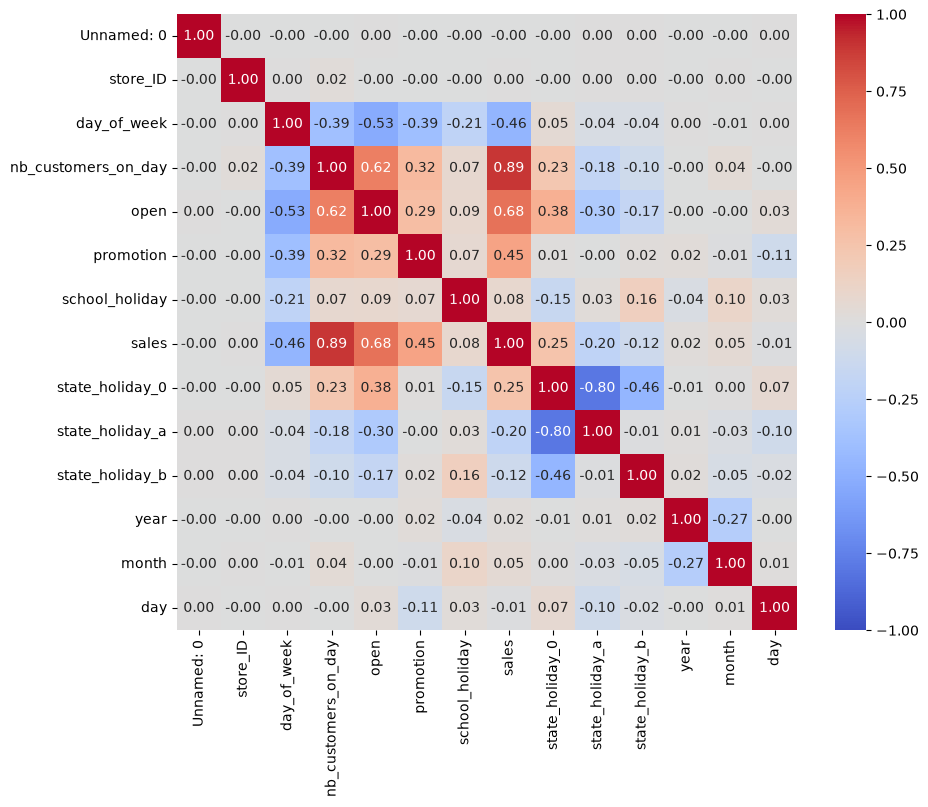

In [14]:
#heatmap to show only columns with a valid correlation
numeric_df = df.select_dtypes(include="number")
numeric_df = numeric_df.loc[:, numeric_df.nunique(dropna=True) > 1]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm",
            vmin=-1, vmax=1, fmt=".2f")
plt.show()

### "store_id" and "Unnamed 0" columns don't have an impact on sales (correlation = 0), so we drop them as they are not useful in the analysis.

In [15]:
#drop the unnecessary columns from the data frame
df =df.drop(columns=["Unnamed: 0", "store_ID"])



In [16]:
display(df)

,day_of_week,nb_customers_on_day,open,promotion,school_holiday,sales,state_holiday_0,state_holiday_a,state_holiday_b,year,month,day
0,4,517,1,0,0,4422,1,0,0,2013,4,18
1,6,694,1,0,0,8297,1,0,0,2015,4,11
2,4,970,1,1,0,9729,1,0,0,2013,8,29
3,2,473,1,1,0,6513,1,0,0,2013,5,28
4,4,1068,1,1,0,10882,1,0,0,2013,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...
640835,6,483,1,0,0,4553,1,0,0,2013,10,26
640836,1,987,1,1,0,12307,1,0,0,2014,4,14
640837,1,925,1,0,0,6800,1,0,0,2014,7,7
640838,4,725,1,0,0,5344,1,0,0,2014,6,12


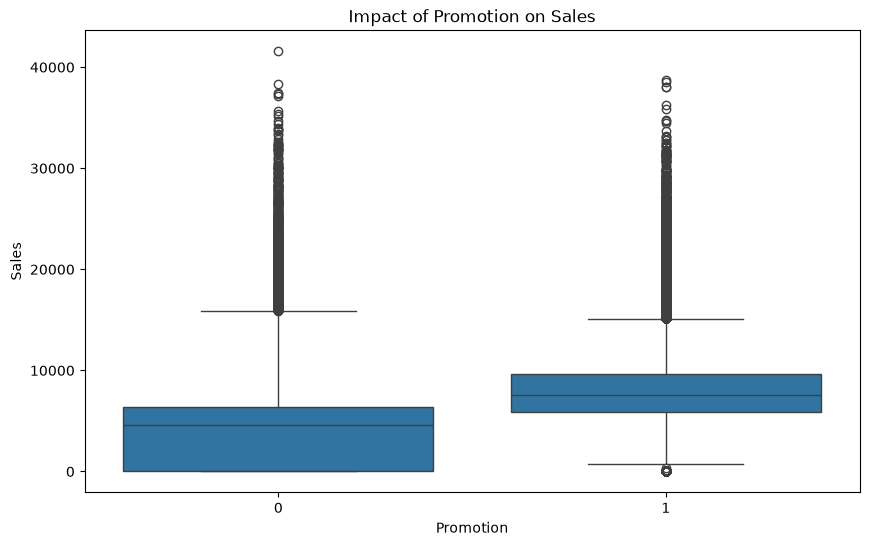

In [17]:
#visualize the impact of Promotion on Sales using a boxplot 
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["promotion"], y=df["sales"], data=df)  
plt.title("Impact of Promotion on Sales")
plt.xlabel("Promotion") 
plt.ylabel("Sales") 
plt.show()

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 640840 entries, 0 to 640839
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   day_of_week          640840 non-null  int64
 1   nb_customers_on_day  640840 non-null  int64
 2   open                 640840 non-null  int64
 3   promotion            640840 non-null  int64
 4   school_holiday       640840 non-null  int64
 5   sales                640840 non-null  int64
 6   state_holiday_0      640840 non-null  int64
 7   state_holiday_a      640840 non-null  int64
 8   state_holiday_b      640840 non-null  int64
 9   year                 640840 non-null  int32
 10  month                640840 non-null  int32
 11  day                  640840 non-null  int32
dtypes: int32(3), int64(9)
memory usage: 51.3 MB


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# 1. Separate features and target
X = df.drop(columns=['sales'])
y = df['sales']

# 2. First split: separate out the test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Second split: split the remaining data into train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)
# 0.25 * 0.8 = 0.2, so overall: 60% train / 20% val / 20% test


In [20]:
# 4. Train the model
modelXGB = XGBRegressor(n_estimators=100, random_state=42)
modelXGB.fit(X_train, y_train,eval_set=[(X_val, y_val)],verbose=False)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [21]:
# 5. Evaluate on validation set
y_val_pred = modelXGB.predict(X_val)
print("Validation MAE:", mean_absolute_error(y_val, y_val_pred))
#print("Validation RMSE:", mean_squared_error(y_val, y_val_pred, squared=False))
print("Validation R²:", r2_score(y_val, y_val_pred))

Validation MAE: 859.7405395507812
Validation R²: 0.8837841749191284


In [22]:
# 6. Final check on test set (only once, after you're happy with tuning)
y_test_pred = modelXGB.predict(X_test)
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))
#print("Test RMSE:", mean_squared_error(y_test, y_test_pred, squared=False))
print("Test R²:", r2_score(y_test, y_test_pred))

Test MAE: 861.591064453125
Test R²: 0.8834972977638245


In [23]:
# 4. Train the second model
modelRandomForest = RandomForestRegressor(n_estimators=100,max_depth=15,n_jobs=-1,random_state=42)
modelRandomForest.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [24]:
# 5. Evaluate on validation set
y_val_pred = modelRandomForest.predict(X_val)
print("Validation R²:", r2_score(y_val, y_val_pred))

# 6. Final check on test set (only once, after you're happy with tuning)
y_test_pred = modelRandomForest.predict(X_test)
print("Test R²:", r2_score(y_test, y_test_pred))

Validation R²: 0.882454189642766
Test R²: 0.8810431635007026


##"Inference Dataset".
###Loading the data from inference.csv

In [25]:
newdf = pd.read_csv('../data/inference.csv')

print("Shape:", newdf.shape)
print("Columns:", newdf.columns)
display(newdf.head())

Shape: (71205, 9)
Columns: Index(['index', 'store_ID', 'day_of_week', 'date', 'nb_customers_on_day',
       'open', 'promotion', 'state_holiday', 'school_holiday'],
      dtype='str')


,index,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday
0,272371,415,7,01/03/2015,0,0,0,0,0
1,558468,27,7,29/12/2013,0,0,0,0,0
2,76950,404,3,19/03/2014,657,1,1,0,0
3,77556,683,2,29/01/2013,862,1,0,0,0
4,456344,920,3,19/03/2014,591,1,1,0,0


In [26]:
# Inference Data Preparation
new_data= newdf.drop(columns=['index','store_ID'])

In [27]:
new_data

,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday
0,7,01/03/2015,0,0,0,0,0
1,7,29/12/2013,0,0,0,0,0
2,3,19/03/2014,657,1,1,0,0
3,2,29/01/2013,862,1,0,0,0
4,3,19/03/2014,591,1,1,0,0
...,...,...,...,...,...,...,...
71200,7,26/10/2014,0,0,0,0,0
71201,7,18/08/2013,0,0,0,0,0
71202,3,11/06/2014,648,1,0,0,0
71203,2,23/04/2013,626,1,1,0,0


In [28]:
##### It is clear that the zero value has a high impact on sales, so we encode the column and keep it. Code:

# Encode categorical values only if the original column is still present
if 'state_holiday' in new_data.columns:
    new_data = pd.get_dummies(new_data, columns=['state_holiday'], dtype=int)

# Drop the reference category if it exists (ignore otherwise)
new_data = new_data.drop(columns=['state_holiday_c'], errors='ignore')

In [29]:
# 2. Convert datetime columns into numeric features (year, month, day)
new_data['date'] = pd.to_datetime(new_data['date'], errors='coerce',format='%d/%m/%Y')
new_data['year'] = new_data['date'].dt.year
new_data['month'] = new_data['date'].dt.month
new_data['day'] = new_data['date'].dt.day
# drop the original datetime column
new_data = new_data.drop(columns=['date'])
# Check data after modifications
new_data.head()

,day_of_week,nb_customers_on_day,open,promotion,school_holiday,state_holiday_0,state_holiday_a,state_holiday_b,year,month,day
0,7,0,0,0,0,1,0,0,2015,3,1
1,7,0,0,0,0,1,0,0,2013,12,29
2,3,657,1,1,0,1,0,0,2014,3,19
3,2,862,1,0,0,1,0,0,2013,1,29
4,3,591,1,1,0,1,0,0,2014,3,19


In [30]:
#push the data in the model for predicting

sale_final_pred = modelXGB.predict(new_data)
print("Final predictions:",sale_final_pred)

Final predictions: [  14.486419  -27.294168 6463.4004   ... 5630.556    6363.6357
 7786.241   ]


In [31]:
#adding predcition to new file
newdf["sales"]= sale_final_pred 
newdf.to_csv('../data/group4.csv', index=False)
newdf.head()

,index,store_ID,day_of_week,date,nb_customers_on_day,open,promotion,state_holiday,school_holiday,sales
0,272371,415,7,01/03/2015,0,0,0,0,0,14.486419
1,558468,27,7,29/12/2013,0,0,0,0,0,-27.294168
2,76950,404,3,19/03/2014,657,1,1,0,0,6463.400391
3,77556,683,2,29/01/2013,862,1,0,0,0,6748.649414
4,456344,920,3,19/03/2014,591,1,1,0,0,6107.312012
